### [ 관심영역 추출 ] <hr>
- 이미지 데이터 수집 / 전처리의 첫번째 단계
- 이미지 데이터 양이 아주 많음 ==> 컴퓨터 메모리/연산, 속도 느려짐
- 필요한 부분만 추출 필수 -> ROI
- 방법
    * (1) numpy로 지정된 위치에 슬라이싱 -> view type으로 copy()필요
    * (2) openCV의 cv2.selectROI() / cv2.selectROIs()

In [1]:
import numpy as np, cv2, matplotlib.pyplot as plt, koreanize_matplotlib, os

In [2]:
IMG_FILE ='../Data/images/bts_01.jpg'
SAVE_DIR = './crop'

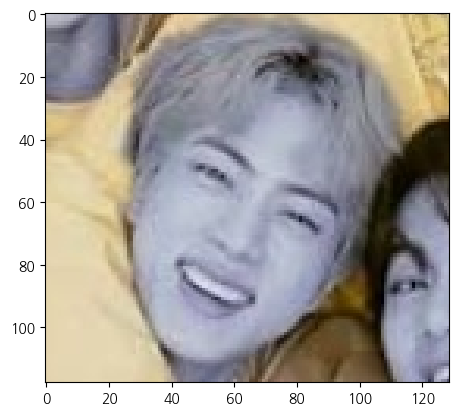

In [4]:
# 이미지 로딩
img = cv2.imread(IMG_FILE)

# roi = cv2.selectROI("select", img)
# plt.imshow(img[roi[1]:roi[1]+roi[3], roi[0]:roi[0]+roi[2]])

x,y,w,h = cv2.selectROI('select', img)
plt.imshow(img[y:y+h, x:x+w])
plt.show()

# cv2.imwrite('./roi.jpg', img[roi[1]:roi[1]+roi[3], roi[0]:roi[0]+roi[2]])
cv2.imwrite('./roi.jpg', img[y:y+h, x:x+w])

cv2.waitKey()
cv2.destroyAllWindows()

In [6]:
# 여러개 ROI 추출
# - 추출 이미지 저장 폴더 : crop
# - 추출 이미지 파일명 형식 : bts_001.jpg

# 저장 폴더 생성
os.makedirs('./bts', exist_ok=True)

# 이미지 로딩
img = cv2.imread(IMG_FILE)

# 여러개 ROI 선택 => space/enter 선택, c 선택 취소, esc 종료
rois = cv2.selectROIs('select', img)
for cnt, (x,y,w,h) in enumerate(rois, 1):
    # roi 부분만 추출
    roi_np = img[y:y+h, x:x+w]
    
    # 파일 저장
    cv2.imwrite(f'./bts/bts_{cnt:03}.jpg', roi_np)

cv2.waitKey()
cv2.destroyAllWindows()